In [2]:
import pandas as pd 
import numpy as np 

# Modeling Results

We have 20000 samples from 10 subjects(each has 2000 samples) and 240 features. We split them into 80%(16,000) and 20%(4,000) train and test data.

In [10]:
data=np.load('all_subjects_wavelet_features_db4_L5.npz',allow_pickle=True)
X=data['X_features']
y=data['y_labels']
print(X.shape)
print(y.shape)
print(np.bincount(y))

(20000, 240)
(20000,)
[2000 2000 2000 2000 2000 2000 2000 2000 2000 2000]


### Train Test Split

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(16000, 240) (4000, 240)
(16000,) (4000,)


We fit them into three models, using random forest as the baseline model, as well as SVM and Logistic regression

## Random Forest

RF Accuracy: 0.71025


<Figure size 800x800 with 0 Axes>

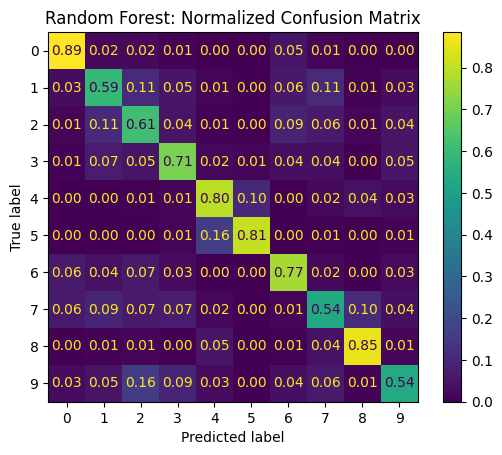

              precision    recall  f1-score   support

           0       0.81      0.89      0.84       400
           1       0.61      0.59      0.60       400
           2       0.56      0.61      0.59       400
           3       0.69      0.71      0.70       400
           4       0.73      0.80      0.76       400
           5       0.88      0.81      0.84       400
           6       0.73      0.77      0.74       400
           7       0.59      0.54      0.56       400
           8       0.83      0.85      0.84       400
           9       0.69      0.54      0.61       400

    accuracy                           0.71      4000
   macro avg       0.71      0.71      0.71      4000
weighted avg       0.71      0.71      0.71      4000



In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay,confusion_matrix
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
acc_rf=accuracy_score(y_test, y_pred_rf)

print("RF Accuracy:", acc_rf)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8,8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    normalize="true",  
    values_format=".2f"
)

plt.title("Random Forest: Normalized Confusion Matrix")
plt.show()
print(classification_report(y_test,y_pred_rf))

## SVM

SVM Accuracy: 0.8205


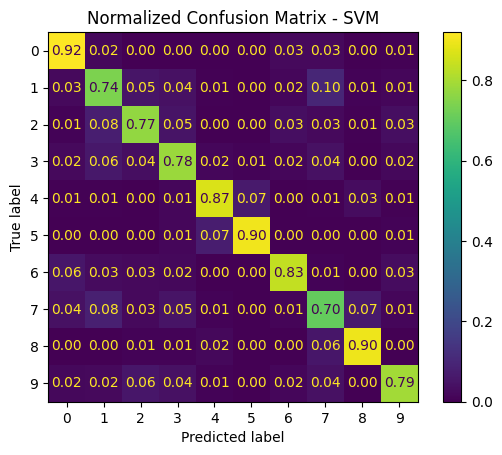

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       400
           1       0.71      0.74      0.73       400
           2       0.79      0.77      0.78       400
           3       0.76      0.78      0.77       400
           4       0.87      0.87      0.87       400
           5       0.92      0.90      0.91       400
           6       0.87      0.83      0.85       400
           7       0.70      0.70      0.70       400
           8       0.89      0.90      0.89       400
           9       0.86      0.79      0.82       400

    accuracy                           0.82      4000
   macro avg       0.82      0.82      0.82      4000
weighted avg       0.82      0.82      0.82      4000



In [26]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import matplotlib.pyplot as plt

svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", random_state=42)
)

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
acc_svm=accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", acc_svm)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    normalize="true",
    values_format=".2f"
)
plt.title("Normalized Confusion Matrix - SVM")
plt.show()
print(classification_report(y_test, y_pred_svm))

## Logistic Regression

Logistic Regression Accuracy: 0.89175


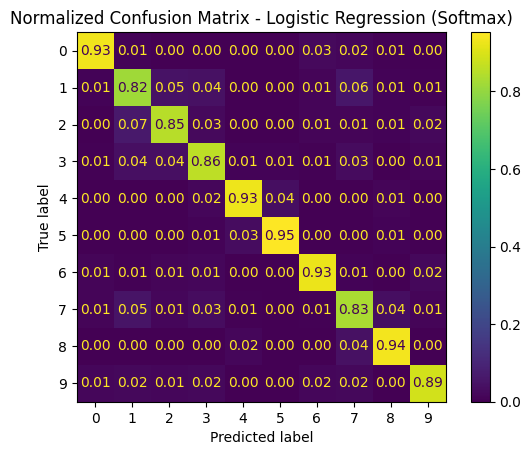

              precision    recall  f1-score   support

           0       0.94      0.93      0.94       400
           1       0.81      0.82      0.81       400
           2       0.86      0.85      0.86       400
           3       0.84      0.86      0.85       400
           4       0.93      0.93      0.93       400
           5       0.95      0.95      0.95       400
           6       0.92      0.93      0.92       400
           7       0.82      0.83      0.82       400
           8       0.92      0.94      0.93       400
           9       0.92      0.89      0.90       400

    accuracy                           0.89      4000
   macro avg       0.89      0.89      0.89      4000
weighted avg       0.89      0.89      0.89      4000



In [28]:
from sklearn.linear_model import LogisticRegression

lr_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        # multi_class="multinomial", 
        solver="lbfgs",
        max_iter=2000,
        random_state=42
    )
)

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
acc_lr=accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:",acc_lr)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    normalize="true",
    values_format=".2f"
)
plt.title("Normalized Confusion Matrix - Logistic Regression (Softmax)")
plt.show()
print(classification_report(y_test, y_pred_lr))

In [33]:
results={'Random Forest':acc_rf,'SVM':acc_svm,'Logistic Regression':acc_lr}
accuracy_comparison = pd.DataFrame({
    "Algorithm": results.keys(),
    "Accuracy": results.values()
})
print(accuracy_comparison)
print(f'Average accuracy is',accuracy_comparison['Accuracy'].mean())

             Algorithm  Accuracy
0        Random Forest   0.71025
1                  SVM   0.82050
2  Logistic Regression   0.89175
Average accuracy is 0.8075000000000001
